In [138]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm

global_path = "/home/ids/edabier/HSU"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
sys.path.append(f"{global_path}/SS-HSU_benchmark")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils, losses, plots, extractor
from src.models import models, upsamplers, foundation_models as rsfm, unmixers as unmx

dev = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_device(dev)
print(f"Using device: {dev}")

Using device: cuda:0


In [139]:
dataset = "urban"
data = io.loadmat(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
Y_init = Y_init.unsqueeze(0)
A_init = A_init.unsqueeze(0)

wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

Y_init_f, A_init_f = rsfm.reshape_Y("DOFA", Y_init, 224, A_init)

features: torch.Size([1024, 196])


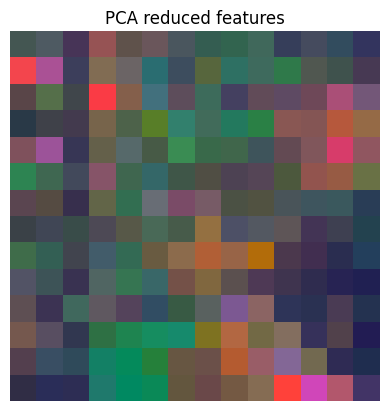

In [140]:
fm_name = "DOFA"
fm, Y_init_f, new_H = rsfm.create_fm(fm_name, Y_init, size="large", version="v1", path=global_path)

_, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths)

D = int(features.shape[0])
alpha = int(features.shape[1]**0.5)

print(f"features: {features.shape}")
plots.plot_pca_features(features)

In [141]:
class PixelShuffle(nn.Module):
    def __init__(self, D, alpha, H):
        super().__init__()
        upsample_factor = H//alpha
        
        self.upsample = nn.Sequential(
            nn.Conv2d(D, D * upsample_factor ** 2, kernel_size=1, groups=D),
            nn.PixelShuffle(upsample_factor),
        )
    
    def forward(self, feat):
        return self.upsample(feat)
    
class FiLMLayer(nn.Module):
    def __init__(self, c, B):
        super().__init__()
        self.gamma = nn.Conv2d(B, c, kernel_size=1)  # Scale
        self.beta = nn.Conv2d(B, c, kernel_size=1)   # Shift

        nn.init.constant_(self.gamma.weight, 1.0)
        nn.init.constant_(self.beta.weight, 0.0)

    def forward(self, x, x_hr):
        # x: (batch, c, H, W)
        # x_hr: (batch, B, H, W)
        gamma = self.gamma(x_hr)  # (batch, c, H, W)
        beta = self.beta(x_hr)    # (batch, c, H, W)
        return x * gamma + beta
    
class FiLMUpsampler(nn.Module):
    def __init__(self, in_channels, out_channels, B, alpha, H, group_channels=False):
        super().__init__()
        
        if group_channels:
            self.upsample = nn.Sequential(
                nn.Upsample(scale_factor=(H // alpha), mode='bilinear', align_corners=False),
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, groups=out_channels),
            )
        else:
            self.upsample = nn.Sequential(
                nn.Upsample(scale_factor=(H // alpha), mode='bilinear', align_corners=False),
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            )
        self.film = FiLMLayer(out_channels, B)

    def forward(self, x_lr, x_hr):
        x_upsampled = self.upsample(x_lr)  # (batch, c, H, H)
        x_fused = self.film(x_upsampled, x_hr)
        return x_fused

In [142]:
# t = torch.rand(1, D, alpha, alpha)
# upsample_factor = new_H // alpha
# # up = nn.Sequential(
# #     nn.Conv2d(D, D * upsample_factor ** 2, kernel_size=1, groups=D),
# #     nn.PixelShuffle(upsample_factor),
# # )
# up = nn.ConvTranspose2d(
#     in_channels=D,
#     out_channels=D,
#     kernel_size=upsample_factor,
#     stride=upsample_factor,
#     padding=0,
#     output_padding=0,
#     groups=D,
# )

# print(up(t).shape)

In [143]:
class UnmixingFromFeatures(nn.Module):
    def __init__(self, D, B, c, H=224, alpha=None):

        super(UnmixingFromFeatures, self).__init__()
        self.D = D
        self.alpha = alpha
        self.B = B
        self.c = c
        self.H = H

        # Upsampling features
        # self.upsample = nn.Linear(self.alpha**2, self.H**2, bias=False)
        # self.upsample = nn.Upsample(H//alpha)
        # self.upsample = FiLMUpsampler(D, D, B, alpha, H, group_channels=False)
        self.upsample = PixelShuffle(D, alpha, H)
        # upsample_factor = H//alpha
        # self.upsample = nn.ConvTranspose2d(
        #     in_channels=D,
        #     out_channels=D,
        #     kernel_size=upsample_factor,
        #     stride=upsample_factor,
        #     padding=0,
        #     output_padding=0,
        #     groups=D)
        
        # Upsampled features to abundances
        self.abundance_estimator = unmx.Abundance_estimator(self.D, self.c, n_features=1)

        self.sum_to_one = unmx.Sum_to_one()
        self.decoder = unmx.Decoder(B=B, c=c)

    @staticmethod
    def weights_init(m):
        if type(m) == nn.Conv2d:
            nn.init.kaiming_normal_(m.weight.data)

    @staticmethod
    def loss(Y_gt, Y_hat, A_hat, E_hat, W_sad=1, W_ab=0.6, W_tv_e=3e-5, W_mse=0.09):
        sad = losses.SADLoss()
        mse = nn.MSELoss(reduction='sum')
        
        loss_sad = W_sad * sad(Y_gt, Y_hat)
        loss_ab = W_ab * torch.sqrt(A_hat).mean()

        loss_mse = W_mse * mse(Y_gt, Y_hat)/(torch.norm(Y_gt)**2)

        """Abundances and endmembers regularisation"""

        # TV on endmembers (sum of difference between consecutive endmembers)
        loss_tv_e = W_tv_e * (torch.abs(E_hat[:, 1:] - E_hat[:, :-1]).sum())

        loss = loss_sad + loss_ab + loss_tv_e + loss_mse

        return loss

    def get_abundances(self, features, Y):

        features = utils.oneD_to_2d(features)
        # print(features.shape)
        # features_up = self.upsample(features.unsqueeze(0), Y)
        features_up = self.upsample(features)
        # features_up = F.interpolate(features.unsqueeze(0), size=(self.H, self.H))
        features_up = features_up.view(
            1, self.D, self.H, self.H
        )

        features_up = utils.standardise(features_up)
        A_hat = self.abundance_estimator(features_up)
        A_hat = self.sum_to_one(A_hat)

        return A_hat
    
    def get_endmembers(self):
        return self.decoder.get_endmembers()
    
    def forward(self, features, Y):
        A_hat = self.get_abundances(features, Y)
        Y_hat = self.decoder(A_hat)
        E_hat = self.decoder.get_endmembers()

        return E_hat, A_hat, Y_hat
 

  0%|          | 0/10 [00:00<?, ?it/s]

{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14


 10%|█         | 1/10 [00:12<01:51, 12.37s/it]

Current SAD = 0.098, NMSE = 1.000
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14


 20%|██        | 2/10 [00:24<01:38, 12.32s/it]

...

Current SAD = 0.117, NMSE = 1.014
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14


 90%|█████████ | 9/10 [01:51<00:12, 12.37s/it]

Current SAD = 0.107, NMSE = 0.971
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14


100%|██████████| 10/10 [02:03<00:00, 12.36s/it]

Current SAD = 0.131, NMSE = 0.994
Average SAD = 0.115, NMSE = 0.992


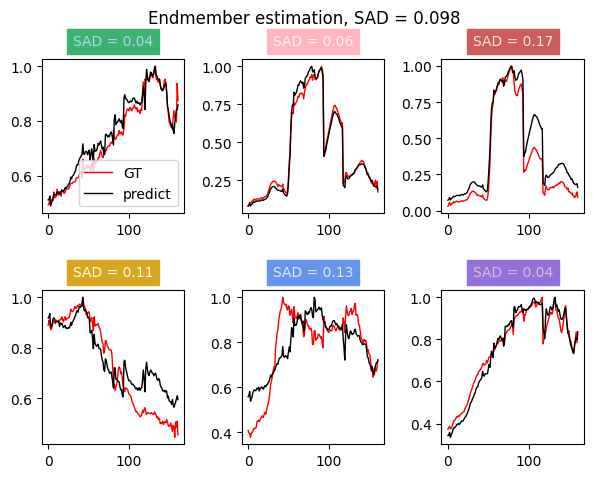

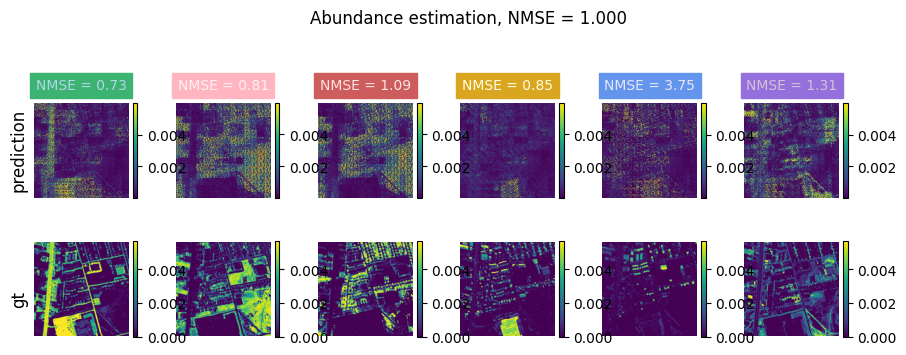

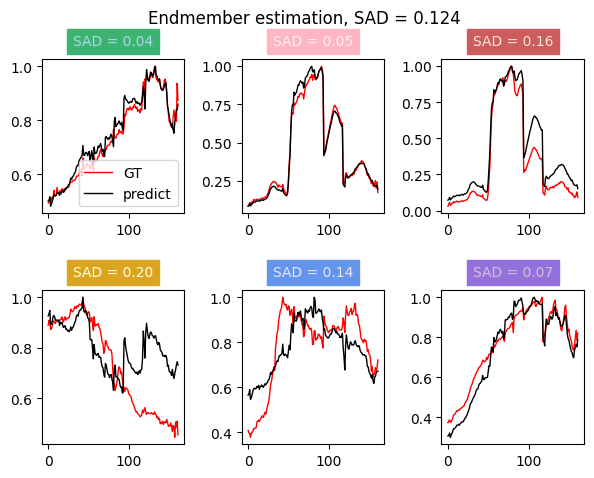

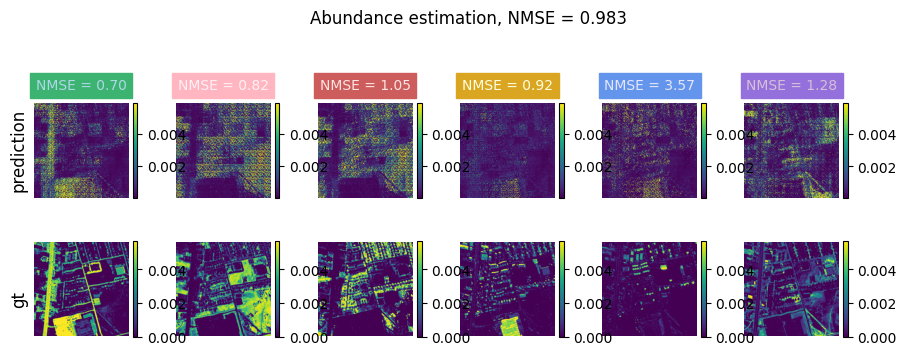

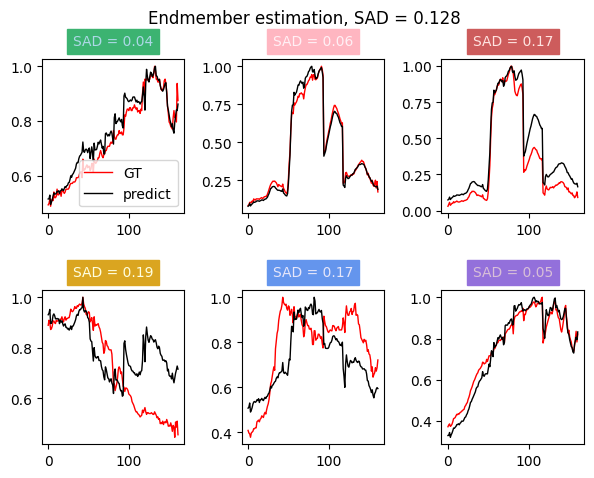

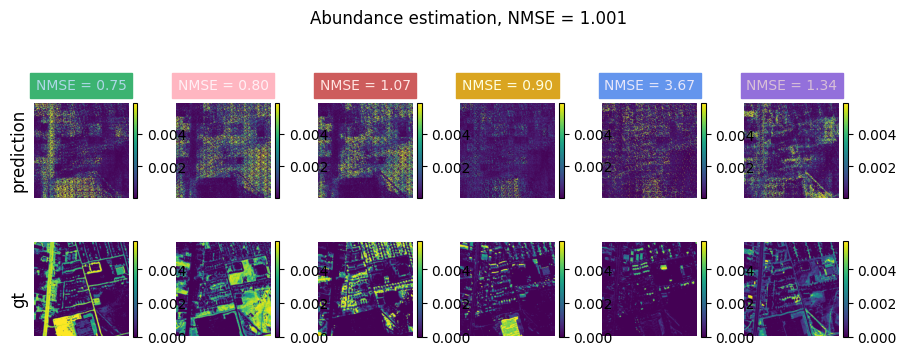

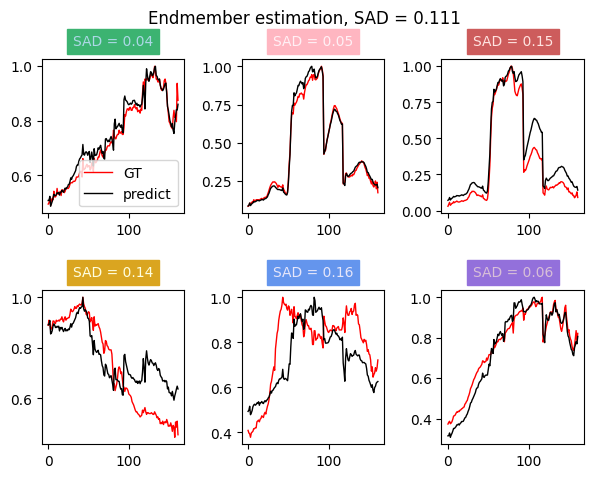

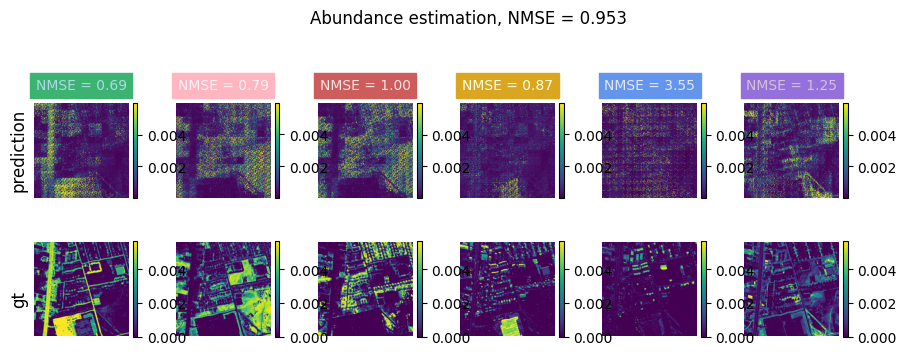

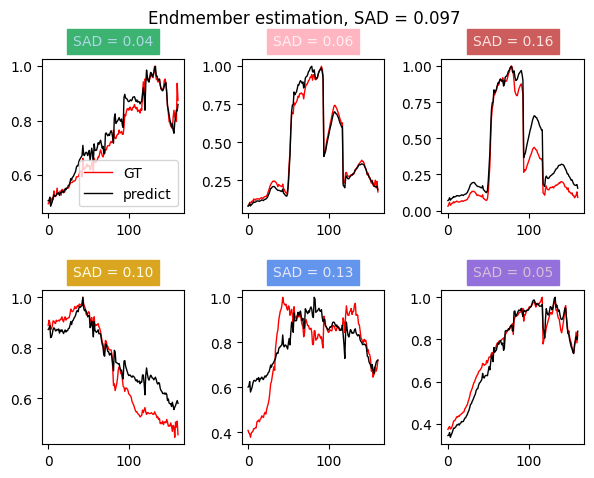

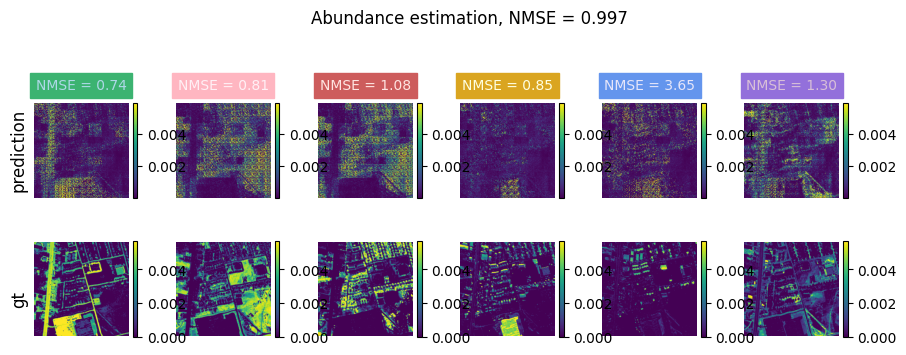

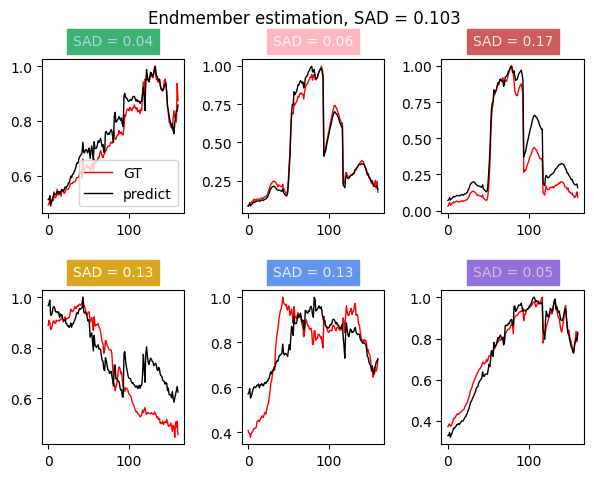

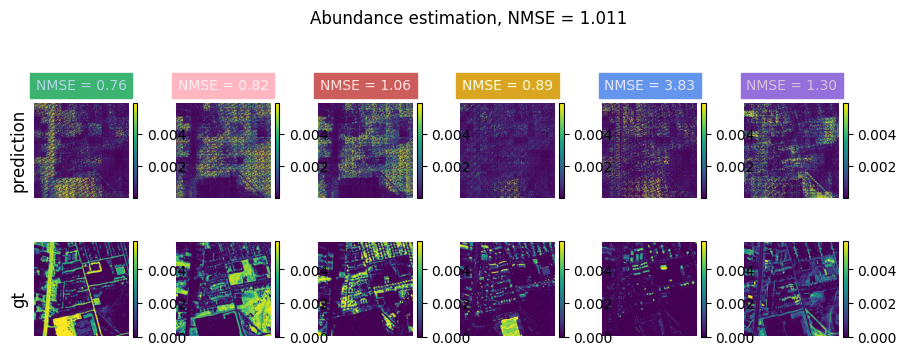

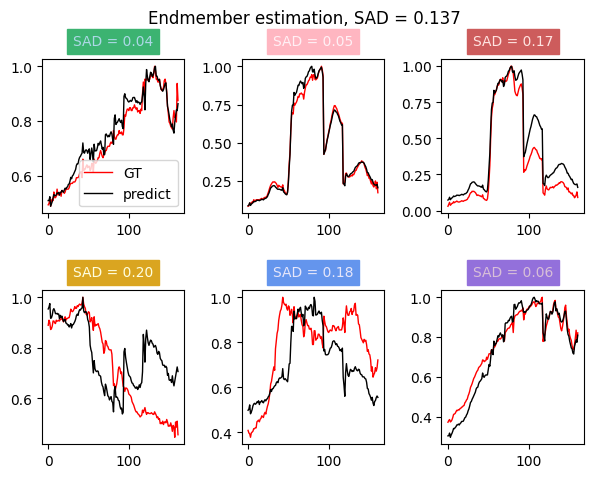

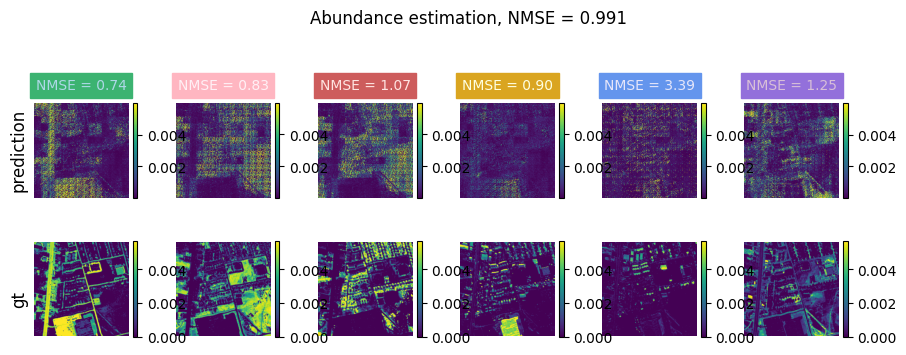

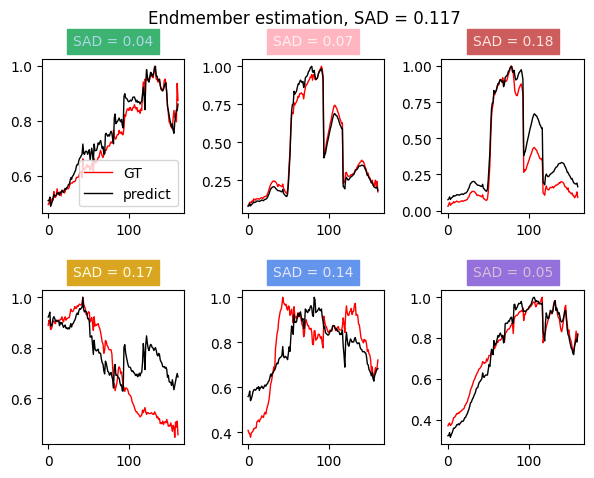

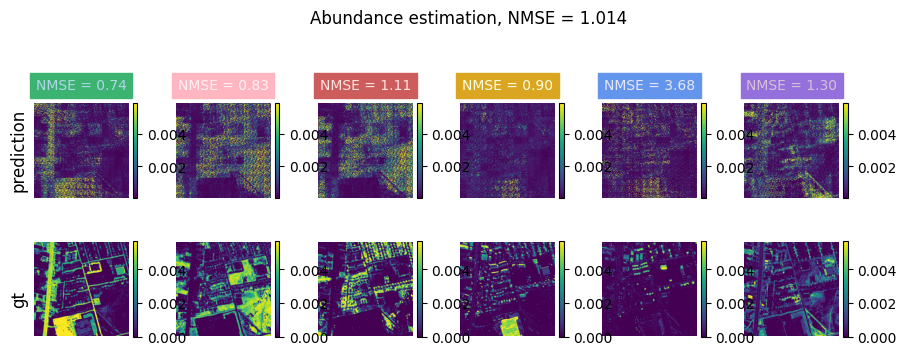

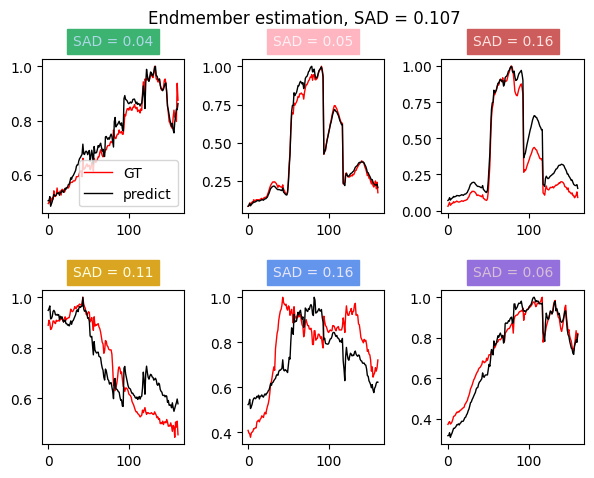

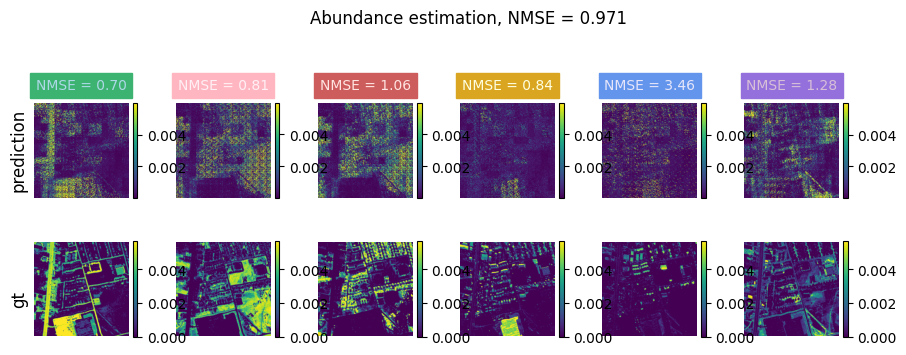

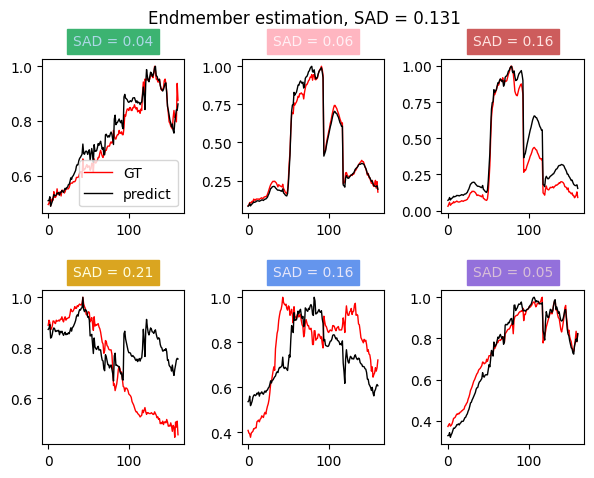

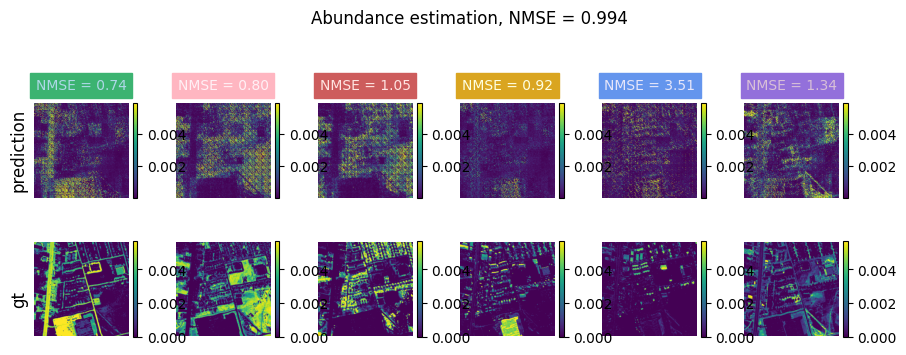

In [144]:
"""Linear upsampling of feature"""

xp = 10
mses, sads = [], []
# up_feat = rsfm.upsample_features(fm, Y_init, wavelengths, new_H, D, alpha)

for x in tqdm(range(xp)):
    loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

    # model = unmx.UnmixingFromUpFeat(D=D, H=new_H, B=B, c=c)
    model = UnmixingFromFeatures(D=D, alpha=alpha, H=new_H, B=B, c=c)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)

            _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
            Y_fm = rsfm.reshape_Y(fm_name, Y, new_H)

            E_hat, A_hat, Y_hat = model(features, Y_fm)
            # E_hat, A_hat, Y_hat = model(up_feat)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
    
    model.eval()
    
    with torch.no_grad():
        
        _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
        Y_fm, A_init_fm = rsfm.reshape_Y(fm_name, Y, new_H, A_init)
        E_hat, A_hat, _ = model(features, Y_fm)

    if E_hat.isnan().any():
        continue
    sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
    mses.append(mse)
    sads.append(sad)
    print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
# print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.2f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.2f')}")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')}")